# PyTorch Workflow

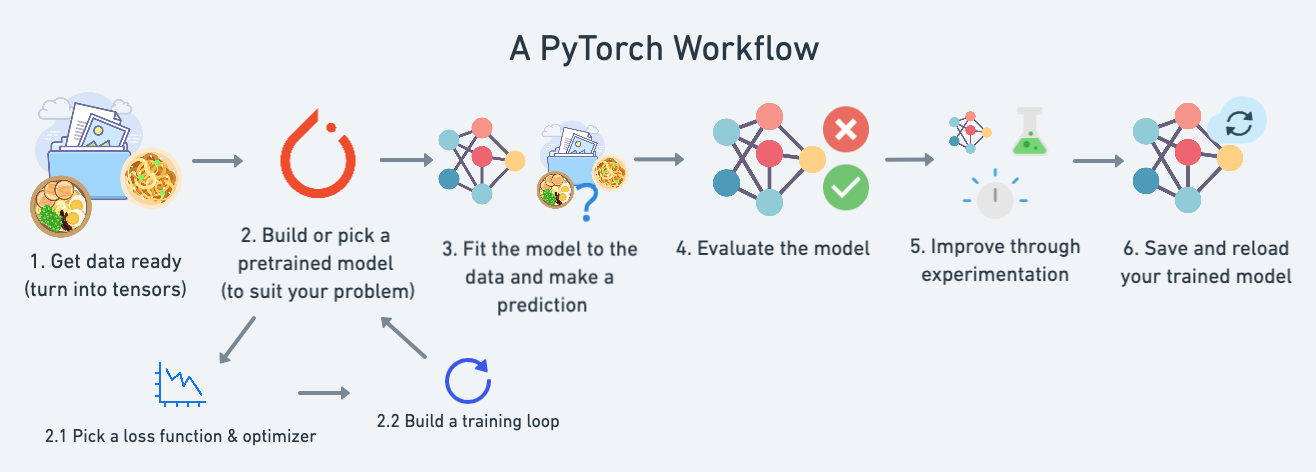

In [55]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [56]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

## 1. Data (preparing and loading)
Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos
* Audios
* DNA
* Text
* ecc

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation


In [57]:
# Create *know* parameters
# y = a + bX, with b = weight and a = bias
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [58]:
X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

### Splitting data into training and test sets

In [59]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

In [60]:
def plot_predictions(train_data= X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  '''
  Plots training data, test data and compares predictions.
  '''
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c='g', s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    # Plot the predictions
    plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

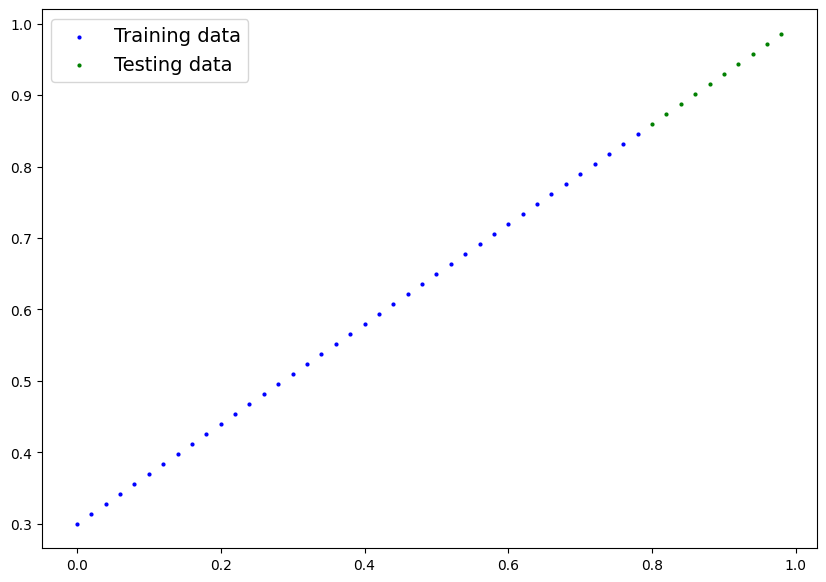

In [61]:
plot_predictions()

## 2. Build a model

What our model does:
* Start with random values (weight and bias)
* Look at training data and adjust those values to better represent the data

How does it do so?

Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [62]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                                requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                            requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

### Checking the contents of our PyTorch model

We can check our model parameters using .parameters()

In [63]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclss of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [64]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using 'torch.inference_mode'

To check our model's predictive power, let's see how well it predicts y_test based on X_test.

In [65]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

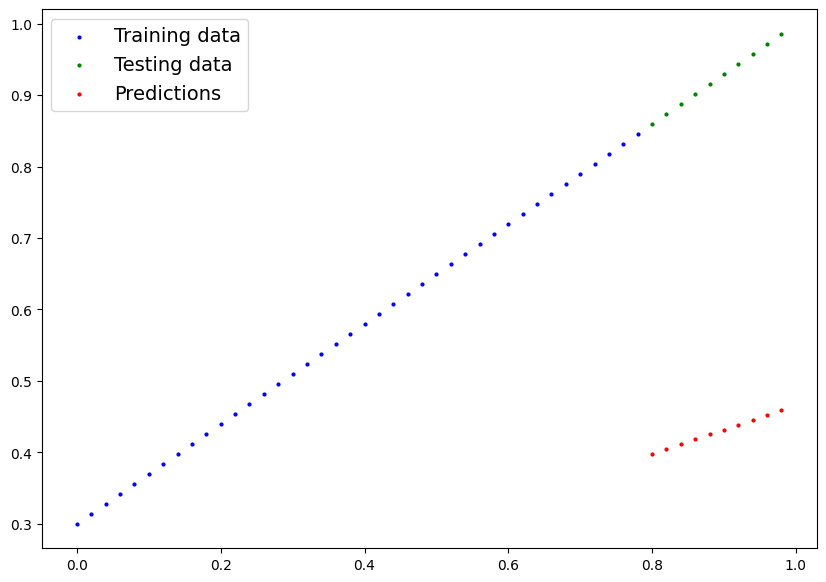

In [66]:
plot_predictions(predictions=y_preds)

## 3. Train model
Right now our model is making predictions using random parameters to make calculations, it's basically guessing (randomly).

To fix that, we can update its internal parameters (I also refer to parameters as patterns), the weights and bias values we set randomly using nn.Parameter() and torch.randn() to be something that better represents the data.

We could hard code this (since we know the default values weight=0.7 and bias=0.3) but where's the fun in that?

Much of the time you won't know what the ideal parameters are for a model.

Instead, it's much more fun to write code to see if the model can try and figure them out itself.


### Things we need to train:

**Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs
**Optimizer:** Takes into account the loss of a model and adjust the model's parameters to improve (minimize) the loss function

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [67]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # learning rate

### Building a training loop in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass (this involves data moving through our model's forward() function) - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parrameters of our model with respect to the loss
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [68]:
torch.manual_seed(42)

# An epoch is one loop through the data...
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train() # Train mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameters of the model (calculate gradients of each parameter)
  loss.backward()

  # 5. Step the optimizer (perform gradient descent in this case)
  optimizer.step() # By default how the optimizer changes will accumulate through the loop so... we have to zero them in step 3 for the next iteration (epoch)


  # Testing
  model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)
  with torch.inference_mode(): # turns off gradient tracking & a couple other things behind the scenes
    # 1. Do forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  # Print out what's happening
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

# Print model state
print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
Epoch: 70 | Loss: 0.03476089984178543 | Test loss: 0.0805937647819519
Epoch: 80 | Loss: 0.03132382780313492 | Test loss: 0.07232122868299484
Epoch: 90 | Loss: 0.02788739837706089 | Test loss: 0.06473556160926819
Epoch: 100 | Loss: 0.024458957836031914 | Test loss: 0.05646304413676262
Epoch: 110 | Loss: 0.021020207554101944 | Test loss: 0.04819049686193466
Epoch: 120 | Loss: 0.01758546568453312 | Test loss: 0.04060482233762741
Epoch: 130 | Loss: 0.014155393466353416 | Test loss: 0.03233227878808975
Ep

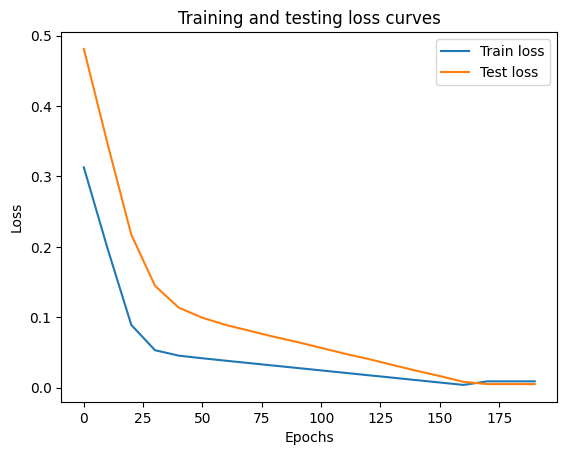

In [69]:
import numpy as np

# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

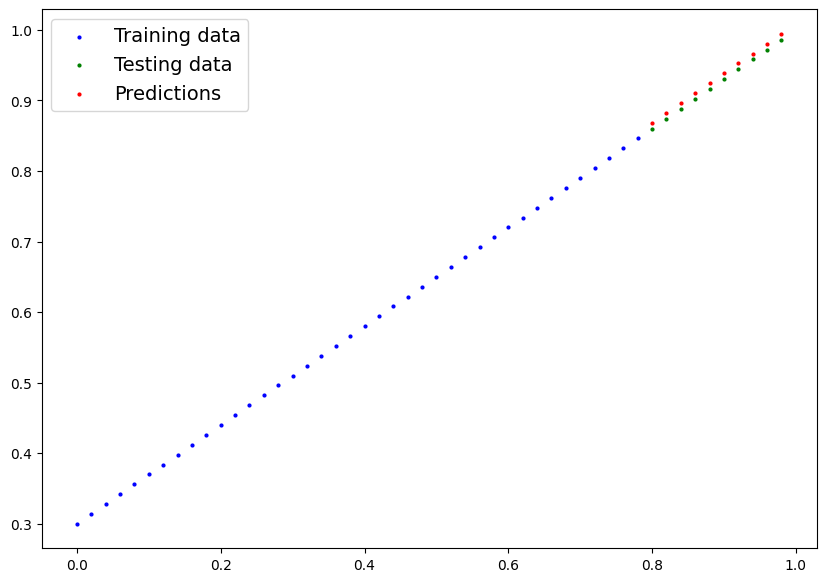

In [70]:
with torch.inference_mode():
  y_preds = model_0(X_test)
  plot_predictions(predictions=y_preds)

## Saving a model in PyTorch

There are three main methods:
1. **torch.save()** - allors you to save a PyTorch object in Python's pickle format
2. **torch.load()** - allows you to load a saved PyTorch object
3. **torch.nn.Module.load_state_dict()** - this allows to load a model's saved state dictionary

In [71]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [72]:
!ls -l models

total 12
-rw-r--r-- 1 root root 2117 Jul 12 16:05 01_pytorch_workflow_model_0.pth
-rw-r--r-- 1 root root 2181 Jul 12 16:03 01_pytorch_workflow_model_1.pth
-rw-r--r-- 1 root root 2181 Jul 12 16:03 01_pytorch_workflow_model_2


## Loading a PyTorch model

Since we saved our model's *state_dict(*) rather then the entire model, we'll create a new instance of our model and load the saved *state_dict()* into that

In [73]:
# Create new model
loaded_model_0 = LinearRegressionModel()

# Load the save state_dict
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [74]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

## 6. Putting it all together

In [75]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check version
torch.__version__

'2.11.0+cpu'

Create device-agnostic code
If we access to GPU then we'll use it, otherwise we'll use the CPU by default

In [76]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


### 6.1 Data

In [77]:
# Create some data using the linear regression formula of y = weight * X + bias
weight = 2
bias = 1.5

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze errors will pop-up
y = weight * X + bias

In [78]:
# Split the data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

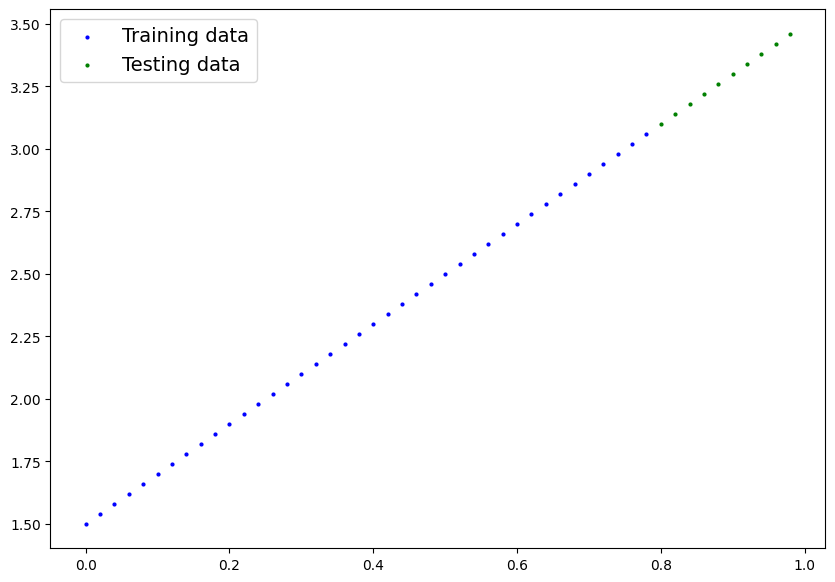

In [79]:
# Plot the data
plot_predictions(X_train, y_train, X_test, y_test)

### 6.2 Building a PyTorch Linear Model

In [80]:
# Create a linear module
class LinearRegressionModelV2(nn.Module):
  def __init__(self) -> None:
     super().__init__()
     # Use nn.Linear() for creating the model parameters
     self.linear_layer = nn.Linear(in_features=1,
                                   out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [81]:
# Check model current device
next(model_1.parameters()).device

device(type='cpu')

In [82]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

### 6.3 Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [83]:
# Setup loss function
loss_fn = nn.L1Loss() # sane as MAE

# Setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [84]:
# Setup training loop
torch.manual_seed(42)

epochs = 400

# Put data on the target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculatre loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

    # Print what's happening
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 1.1518219709396362 | Test loss: 1.7560818195343018
Epoch: 10 | Loss: 1.0366121530532837 | Test loss: 1.6213719844818115
Epoch: 20 | Loss: 0.9214023351669312 | Test loss: 1.4866621494293213
Epoch: 30 | Loss: 0.8061923980712891 | Test loss: 1.3519524335861206
Epoch: 40 | Loss: 0.6909826397895813 | Test loss: 1.2172425985336304
Epoch: 50 | Loss: 0.5757726430892944 | Test loss: 1.0825326442718506
Epoch: 60 | Loss: 0.4605628550052643 | Test loss: 0.9478228688240051
Epoch: 70 | Loss: 0.34874090552330017 | Test loss: 0.8156212568283081
Epoch: 80 | Loss: 0.2706054151058197 | Test loss: 0.7036590576171875
Epoch: 90 | Loss: 0.2223912924528122 | Test loss: 0.6143323183059692
Epoch: 100 | Loss: 0.19272033870220184 | Test loss: 0.5431315302848816
Epoch: 110 | Loss: 0.17477412521839142 | Test loss: 0.4877870976924896
Epoch: 120 | Loss: 0.16349413990974426 | Test loss: 0.44505101442337036
Epoch: 130 | Loss: 0.15593324601650238 | Test loss: 0.4113524556159973
Epoch: 140 | Loss: 0.1504

In [85]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[1.7052]])),
             ('linear_layer.bias', tensor([1.6235]))])

### 6.4 Making and evaluating predictions

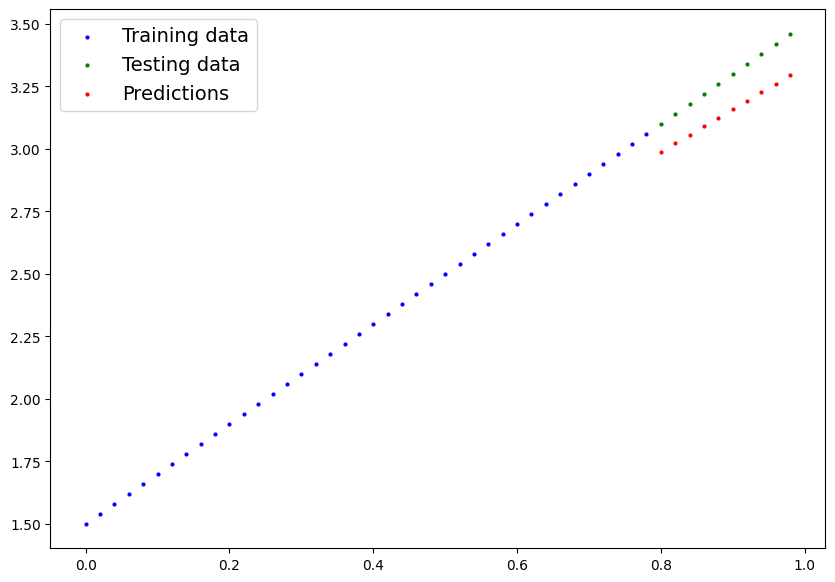

In [86]:
# Turn model into eval mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
  plot_predictions(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu(), y_preds.cpu())

### 6.5 Saving & loading a trained model

In [87]:
# Saving the model
from pathlib import Path

# Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving the model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving the model to: models/01_pytorch_workflow_model_1.pth


In [88]:
# Loading the model
# Create a new model
loaded_model_1 = LinearRegressionModelV2()

# Load the state dict into the model
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [89]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [90]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[1.7052]])),
             ('linear_layer.bias', tensor([1.6235]))])

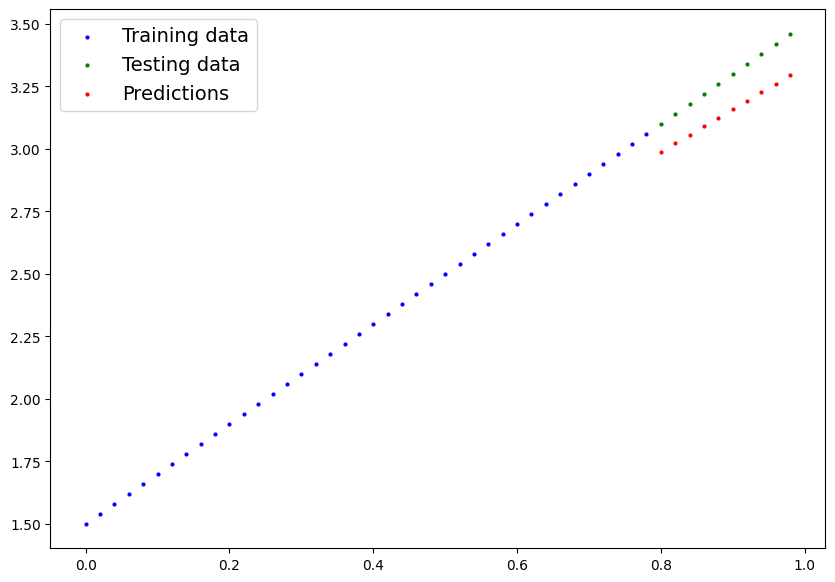

In [91]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
  y_preds = loaded_model_1(X_test)

plot_predictions(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu(), y_preds.cpu())

## Exercises

In [92]:
# Imports
import torch
from torch import nn
import matplotlib.pyplot as plt

In [93]:
# Setup device-agnostic code
target_device = "cuda" if torch.cuda.is_available() else "cpu"
torch.device(target_device)

device(type='cpu')

In [94]:
# Create data params
weight = 0.3
bias = 0.9

# Create data
start = 0
end = 2
step = 0.02

X = torch.arange(start, end, step, device=target_device).unsqueeze(dim=1)
y = weight * X + bias

# Split data into training and testing data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [95]:
# Visualize data
def plot_data(X_train,
              y_train,
              X_test,
              y_test,
              y_pred=None):
  # Move tensors to cpu
  X_train, y_train = X_train.cpu(), y_train.cpu()
  X_test, y_test = X_test.cpu(), y_test.cpu()

  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(X_train, y_train, c='b', label="Training data")

  # Plot test data in green
  plt.scatter(X_test, y_test, c='g', label="Training data")

  # Plot predictions if there are any
  if y_pred is not None:
    plt.scatter(X_test, y_pred.cpu(), c='r', label="Predictions")

  # Show the legend
  plt.legend(prop={"size":14})

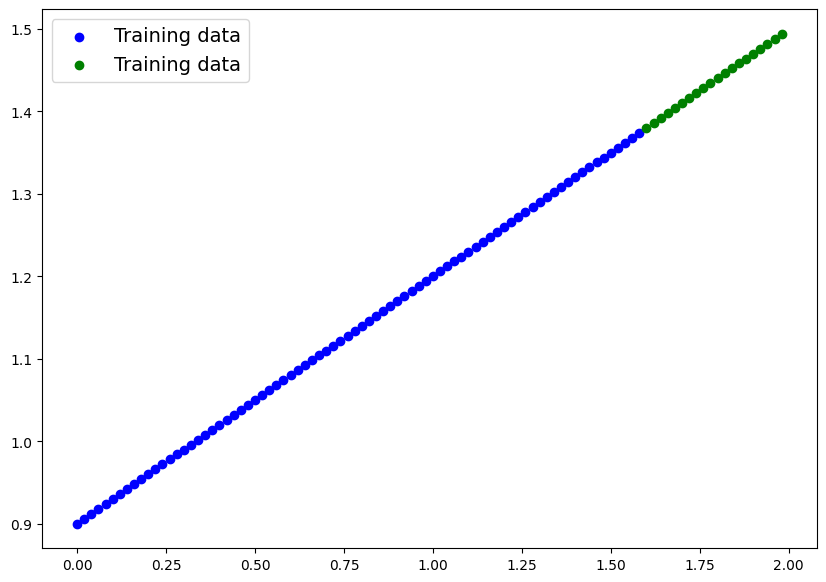

In [96]:
plot_data(X_train, y_train, X_test, y_test)

In [97]:
# Create PyTorch linear regression model
class LinearRegressionModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [98]:
# Instantiate the model and put on target device
model_2 = LinearRegressionModelV3()
model_2.to(device)
model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.2343]])),
             ('linear_layer.bias', tensor([0.9186]))])

In [99]:
# Create a loss function and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(model_2.parameters(),
                            lr=0.01)

In [100]:
# Training loop


# Train model for 300 epochs
epochs = 300

for epoch in range(epochs):
  ### Training

  # Put model in train mode
  model_2.train()

  # 1. Forward pass
  y_preds = model_2(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_preds, y_train)

  # 3. Zero gradients
  optimizer.zero_grad()

  # 4. Backpropagation
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Perform testing every 20 epochs
  if epoch % 20 == 0:

    # Put model in evaluation mode and setup inference context
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_preds = model_2(X_test)

      # 2. Calculate test loss
      test_loss = loss_fn(test_preds, y_test)

      # Print out what's happening
      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.404 | Test loss: 0.914
Epoch: 20 | Train loss: 0.186 | Test loss: 0.509
Epoch: 40 | Train loss: 0.109 | Test loss: 0.269
Epoch: 60 | Train loss: 0.085 | Test loss: 0.176
Epoch: 80 | Train loss: 0.067 | Test loss: 0.133
Epoch: 100 | Train loss: 0.049 | Test loss: 0.095
Epoch: 120 | Train loss: 0.030 | Test loss: 0.059
Epoch: 140 | Train loss: 0.012 | Test loss: 0.023
Epoch: 160 | Train loss: 0.013 | Test loss: 0.003
Epoch: 180 | Train loss: 0.013 | Test loss: 0.003
Epoch: 200 | Train loss: 0.013 | Test loss: 0.003
Epoch: 220 | Train loss: 0.013 | Test loss: 0.003
Epoch: 240 | Train loss: 0.013 | Test loss: 0.003
Epoch: 260 | Train loss: 0.013 | Test loss: 0.003
Epoch: 280 | Train loss: 0.013 | Test loss: 0.003


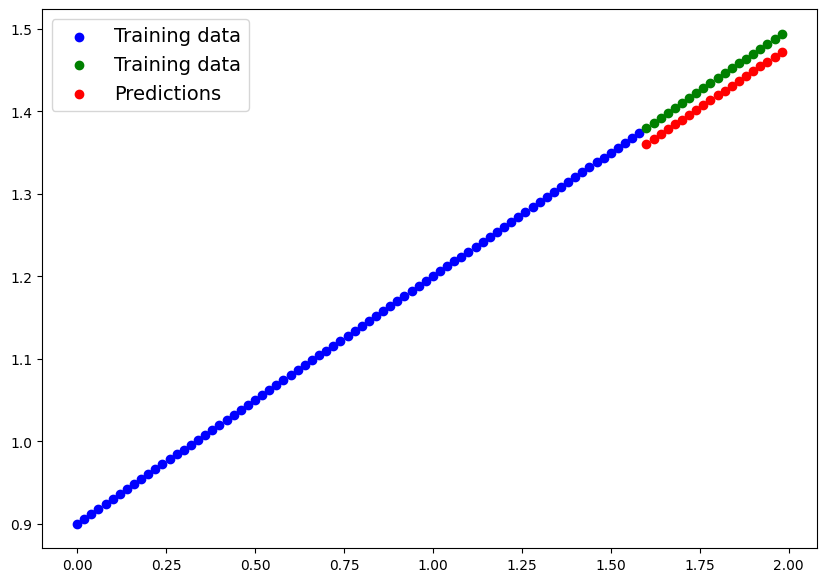

In [101]:
# Make predictions with the model
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test)

plot_data(X_train, y_train, X_test, y_test, y_preds)

In [102]:
# Save model
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_2"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_2


In [104]:
# Load model
loaded_model_2 = LinearRegressionModelV3()
loaded_model_2.to(device)
loaded_model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.2925]])),
             ('linear_layer.bias', tensor([0.8929]))])

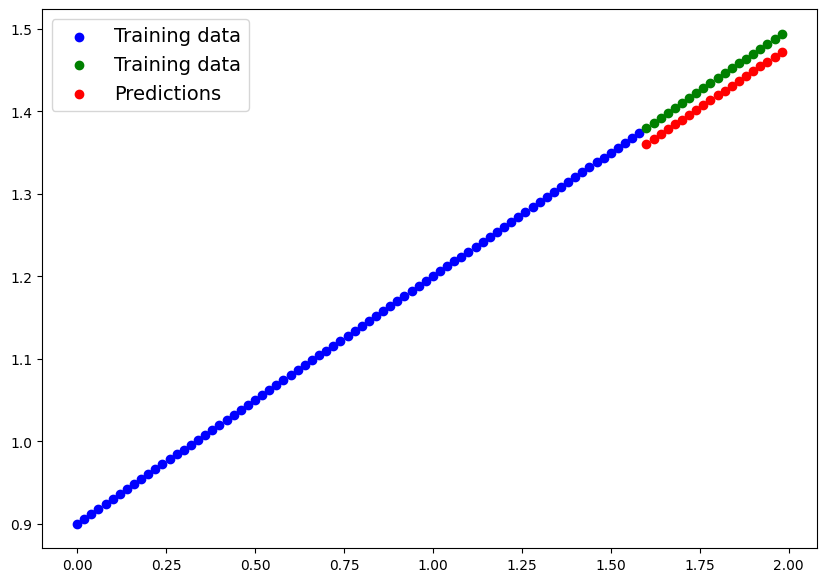

In [105]:
# Make preds
loaded_model_2.eval()
with torch.inference_mode():
  y_preds = loaded_model_2(X_test)

plot_data(X_train, y_train, X_test, y_test, y_preds)